# Isomap — Jeu de données COIL-100
Ce notebook charge le jeu de données COIL-100 (images d'objets photographiés sous différents angles),
applique une pipeline Isomap avec séparation train / validation / test (70/15/15).
Il entraîne Isomap avec optimisation d'hyperparamètres via Optuna, valide les résultats, et affiche les métriques de qualité d'embedding.

In [1]:
# Importations
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
# Chargement du jeu de données COIL-100 depuis le répertoire local
repertoire_donnees = r'D:\100DaysofML\Notebooks\080_Isomap\coil-100'

images = []
etiquettes = []
taille_cible = (32, 32)  # Redimensionner en 32x32 pour la faisabilité du calcul

for nom_fichier in sorted(os.listdir(repertoire_donnees)):
    if nom_fichier.endswith('.png') and nom_fichier.startswith('obj'):
        # Extraire l'identifiant de l'objet (ex: obj12__45.png -> 12)
        id_objet = int(nom_fichier.split('__')[0].replace('obj', ''))
        chemin_image = os.path.join(repertoire_donnees, nom_fichier)
        img = Image.open(chemin_image).convert('L')  # Conversion en niveaux de gris
        img = img.resize(taille_cible)
        images.append(np.array(img).flatten())
        etiquettes.append(id_objet)

X = np.array(images, dtype=np.float64)
y = np.array(etiquettes)

print('Jeu de données chargé avec succès !')
print('Forme de X :', X.shape)
print('Forme de y :', y.shape)
print('Nombre de classes :', len(np.unique(y)))
print('Échantillons par classe :', np.bincount(y)[np.unique(y)][0], '(chaque objet possède 72 vues)')

Jeu de données chargé avec succès !
Forme de X : (7200, 1024)
Forme de y : (7200,)
Nombre de classes : 100
Échantillons par classe : 72 (chaque objet possède 72 vues)


In [3]:
# Séparation Train / Validation / Test (70/15/15)
# Première séparation : 70% entraînement, 30% temporaire (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
# Deuxième séparation : 50/50 du temporaire pour obtenir 15% val et 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print('Séparation Train / Validation / Test (70/15/15) :')
print('Forme X_train :', X_train.shape)
print('Forme X_val :', X_val.shape)
print('Forme X_test :', X_test.shape)

Séparation Train / Validation / Test (70/15/15) :
Forme X_train : (5040, 1024)
Forme X_val : (1080, 1024)
Forme X_test : (1080, 1024)


In [ ]:
# Recherche d'hyperparamètres avec Optuna sur le jeu d'entraînement uniquement
try:
    import optuna
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna'])
    import optuna

from sklearn.manifold import trustworthiness

# Normalisation des données d'entraînement pour les essais Optuna
normaliseur_opt = StandardScaler()
X_train_normalise = normaliseur_opt.fit_transform(X_train)

def objectif(essai):
    n_composantes = essai.suggest_int('n_components', 2, 15)
    n_voisins = essai.suggest_int('n_neighbors', 5, 30)
    metrique = essai.suggest_categorical('metric', ['euclidean', 'minkowski', 'cosine'])
    p = essai.suggest_int('p', 1, 3) if metrique == 'minkowski' else 2

    try:
        isomap = Isomap(
            n_components=n_composantes,
            n_neighbors=n_voisins,
            metric=metrique,
            p=p
        )
        X_reduit = isomap.fit_transform(X_train_normalise)

        # Fidélité (trustworthiness) : mesure la préservation de la structure locale (plus élevé = mieux)
        fidelite = trustworthiness(X_train_normalise, X_reduit, n_neighbors=min(5, n_voisins))

        # Erreur de reconstruction d'Isomap (plus faible = mieux)
        erreur_recon = isomap.reconstruction_error()

        # Score combiné : maximiser la fidélité, minimiser l'erreur de reconstruction
        # On inverse la fidélité car Optuna minimise par défaut
        score = -fidelite + 0.001 * erreur_recon
        return score
    except Exception as e:
        print(f'Essai échoué : {e}')
        return float('inf')

etude = optuna.create_study(direction='minimize')
etude.optimize(objectif, n_trials=50, show_progress_bar=False)

meilleurs_params = etude.best_trial.params
meilleur_n_composantes = meilleurs_params['n_components']
meilleur_n_voisins = meilleurs_params['n_neighbors']
meilleure_metrique = meilleurs_params['metric']
meilleur_p = meilleurs_params.get('p', 2)

print('Meilleurs hyperparamètres trouvés :')
print(meilleurs_params)
print('Meilleur score (score combiné) :', etude.best_value)

[I 2026-05-04 10:30:13,322] A new study created in memory with name: no-name-287754ff-826e-4681-a9be-3ef057e0a349
C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess

Meilleurs hyperparamètres trouvés :
{'n_components': 15, 'n_neighbors': 17, 'metric': 'cosine'}
Meilleur score (score combiné) : -0.9940630515995291


In [ ]:
# Étape de validation : évaluer les meilleurs hyperparamètres sur le jeu de validation
pipeline_val = make_pipeline(
    StandardScaler(),
    Isomap(
        n_components=meilleur_n_composantes,
        n_neighbors=meilleur_n_voisins,
        metric=meilleure_metrique,
        p=meilleur_p
    )
)

# Ajustement sur les données d'entraînement
pipeline_val.fit(X_train)
X_train_reduit = pipeline_val.transform(X_train)
X_val_reduit = pipeline_val.transform(X_val)

print('Étape de validation — Performance des meilleurs hyperparamètres :')
print('Forme X_train (original) :', X_train.shape)
print('Forme X_train (réduit) :', X_train_reduit.shape)
print('Forme X_val (réduit) :', X_val_reduit.shape)
print('✓ Jeu de validation prêt pour évaluation')

C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 4 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  sel

Étape de validation — Performance des meilleurs hyperparamètres :
Forme X_train (original) : (5040, 1024)
Forme X_train (réduit) : (5040, 15)
Forme X_val (réduit) : (1080, 15)
✓ Jeu de validation prêt pour évaluation


In [6]:
# Étape finale : réentraîner sur train+validation, puis évaluer sur test
X_train_complet = np.vstack([X_train, X_val])
y_train_complet = np.hstack([y_train, y_val])

pipeline_final = make_pipeline(
    StandardScaler(),
    Isomap(
        n_components=meilleur_n_composantes,
        n_neighbors=meilleur_n_voisins,
        metric=meilleure_metrique,
        p=meilleur_p
    )
)

# Ajustement sur les données combinées train+val
pipeline_final.fit(X_train_complet)
X_train_complet_reduit = pipeline_final.transform(X_train_complet)
X_test_reduit = pipeline_final.transform(X_test)

print('=' * 60)
print('MODÈLE FINAL — PHASE DE TEST')
print('=' * 60)
print('Forme train+val (réduit) :', X_train_complet_reduit.shape)
print('Forme test (réduit) :', X_test_reduit.shape)

C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 6 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  sel

MODÈLE FINAL — PHASE DE TEST
Forme train+val (réduit) : (6120, 15)
Forme test (réduit) : (1080, 15)


In [7]:
# Métriques d'évaluation Isomap : validation et test uniquement
from sklearn.manifold import trustworthiness
from scipy.spatial.distance import pdist, squareform


def score_continuite(X_orig, X_reduit, n_voisins=5):
    """Score de continuité dans [0, 1]. Plus élevé = mieux."""
    n_echantillons = X_orig.shape[0]
    if n_echantillons <= n_voisins + 1:
        raise ValueError("Pas assez d'échantillons pour calculer la continuité.")

    dist_orig = squareform(pdist(X_orig, metric='euclidean'))
    dist_red = squareform(pdist(X_reduit, metric='euclidean'))

    voisins_orig = np.argsort(dist_orig, axis=1)[:, 1:n_voisins + 1]
    voisins_red = np.argsort(dist_red, axis=1)[:, 1:n_voisins + 1]

    somme_c = 0.0
    for i in range(n_echantillons):
        manquants = np.setdiff1d(voisins_orig[i], voisins_red[i], assume_unique=False)
        for voisin in manquants:
            rang_red = np.where(np.argsort(dist_red[i]) == voisin)[0]
            if rang_red.size > 0:
                r = int(rang_red[0])
                if r > n_voisins:
                    somme_c += r - n_voisins

    denominateur = n_echantillons * n_voisins * (2 * n_echantillons - 3 * n_voisins - 1)
    return 1.0 - (2.0 / denominateur) * somme_c


print('\n' + '=' * 72)
print('MÉTRIQUES D\'ÉVALUATION ISOMAP')
print('=' * 72)
print(f'Hyperparamètres : n_components={meilleur_n_composantes}, n_neighbors={meilleur_n_voisins}, metric={meilleure_metrique}, p={meilleur_p}')
print('Voisinage pour les métriques k = 5')

# Récupérer le normaliseur de la pipeline finale pour normaliser val et test
normaliseur_final = pipeline_final[0]
X_val_normalise = normaliseur_final.transform(X_val)
X_test_normalise = normaliseur_final.transform(X_test)

X_val_reduit_final = X_train_complet_reduit[X_train.shape[0]:]

lignes = []
for nom_partition, X_partition_norm, X_partition_reduit in [
    ('Validation', X_val_normalise, X_val_reduit_final),
    ('Test', X_test_normalise, X_test_reduit),
]:
    lignes.append({
        'Partition': nom_partition,
        'Fidélité (Trustworthiness)': trustworthiness(X_partition_norm, X_partition_reduit, n_neighbors=5),
        'Continuité': score_continuite(X_partition_norm, X_partition_reduit, n_voisins=5),
    })

df_metriques = pd.DataFrame(lignes)
df_metriques_affichage = df_metriques.copy()
for col in ['Fidélité (Trustworthiness)', 'Continuité']:
    df_metriques_affichage[col] = df_metriques_affichage[col].map(lambda x: f'{x:.4f}')

display(df_metriques_affichage)



MÉTRIQUES D'ÉVALUATION ISOMAP
Hyperparamètres : n_components=15, n_neighbors=17, metric=cosine, p=2
Voisinage pour les métriques k = 5


,Partition,Fidélité (Trustworthiness),Continuité
0,Validation,0.9703,0.9832
1,Test,0.9732,0.9834


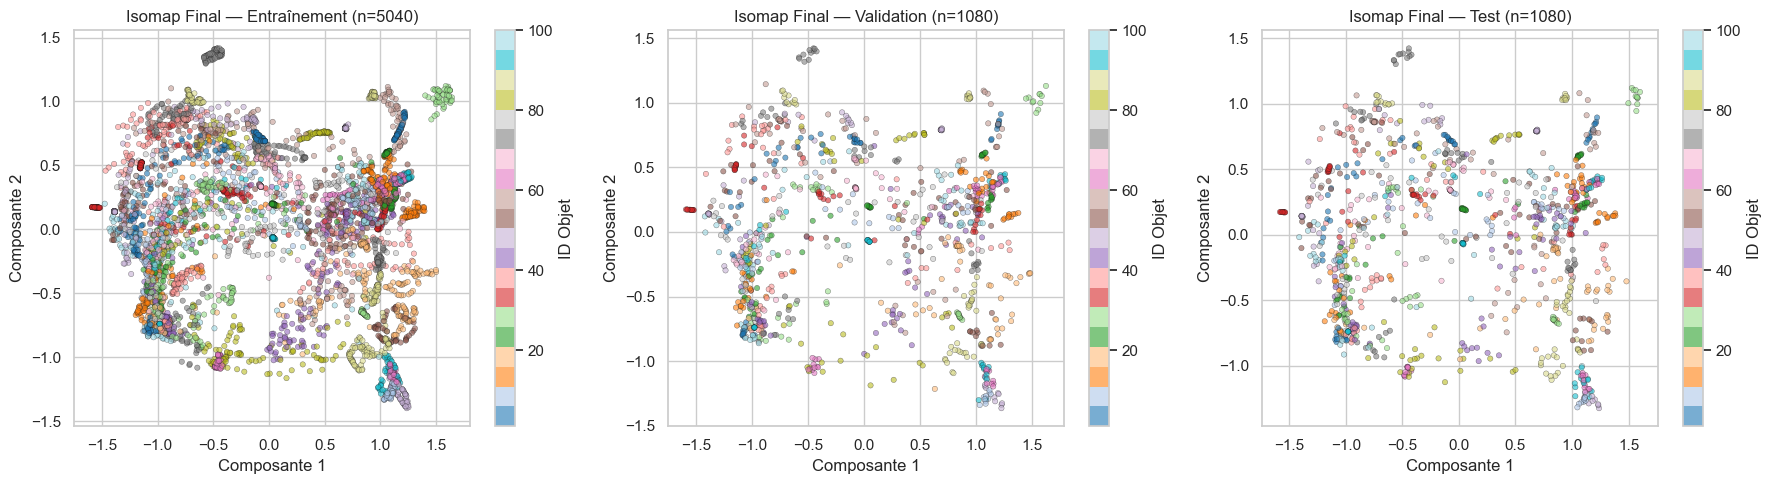

In [ ]:
# Visualisation finale : les trois ensembles (entraînement, validation, test)
if meilleur_n_composantes >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Extraire entraînement et validation de l'ensemble réduit complet
    X_train_reduit_final = X_train_complet_reduit[:X_train.shape[0]]
    X_val_reduit_final = X_train_complet_reduit[X_train.shape[0]:]
    
    # Ensemble d'entraînement (modèle final)
    nuage_train = axes[0].scatter(
        X_train_reduit_final[:, 0],
        X_train_reduit_final[:, 1],
        c=y_train,
        cmap='tab20',
        alpha=0.6,
        edgecolors='k',
        s=15,
        linewidths=0.3
    )
    axes[0].set_xlabel('Composante 1')
    axes[0].set_ylabel('Composante 2')
    axes[0].set_title(f'Isomap Final — Entraînement (n={X_train.shape[0]})')
    plt.colorbar(nuage_train, ax=axes[0], label='ID Objet')
    
    # Ensemble de validation (modèle final)
    nuage_val = axes[1].scatter(
        X_val_reduit_final[:, 0],
        X_val_reduit_final[:, 1],
        c=y_val,
        cmap='tab20',
        alpha=0.6,
        edgecolors='k',
        s=15,
        linewidths=0.3
    )
    axes[1].set_xlabel('Composante 1')
    axes[1].set_ylabel('Composante 2')
    axes[1].set_title(f'Isomap Final — Validation (n={X_val.shape[0]})')
    plt.colorbar(nuage_val, ax=axes[1], label='ID Objet')
    
    # Ensemble de test (modèle final)
    nuage_test = axes[2].scatter(
        X_test_reduit[:, 0],
        X_test_reduit[:, 1],
        c=y_test,
        cmap='tab20',
        alpha=0.6,
        edgecolors='k',
        s=15,
        linewidths=0.3
    )
    axes[2].set_xlabel('Composante 1')
    axes[2].set_ylabel('Composante 2')
    axes[2].set_title(f'Isomap Final — Test (n={X_test.shape[0]})')
    plt.colorbar(nuage_test, ax=axes[2], label='ID Objet')
    
    plt.tight_layout()
    plt.show()
